# Unemployment Analysis in India

## Objective
To analyze unemployment trends in India, compare unemployment across regions and states, and study the impact of COVID-19 on unemployment.

In [21]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [22]:
# Load the unemployment dataset

df = pd.read_csv("Unemployment in India.csv")

# Display the first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [23]:
# Check the number of rows and columns

df.shape

(768, 7)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [25]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [26]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [27]:
df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [28]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Date'].head()

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]

In [29]:
df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

In [30]:
numeric_cols = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB


In [31]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

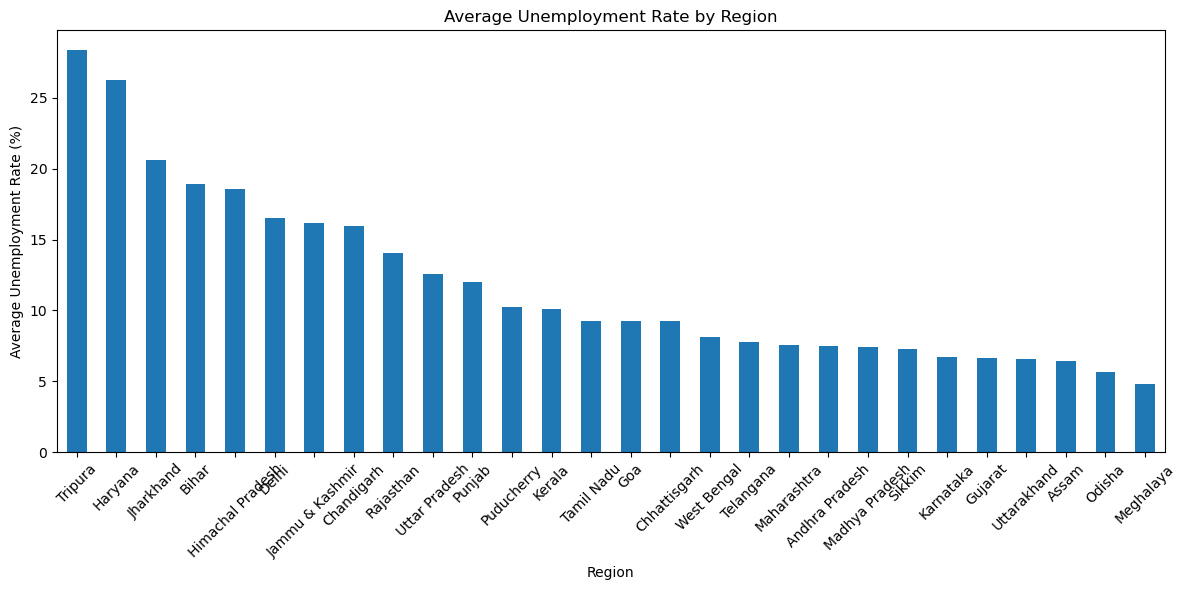

In [32]:
plt.figure(figsize=(12,6))

region_avg.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation: The chart shows differences in average unemployment rates across regions of India. Some regions experience considerably higher unemployment than others.

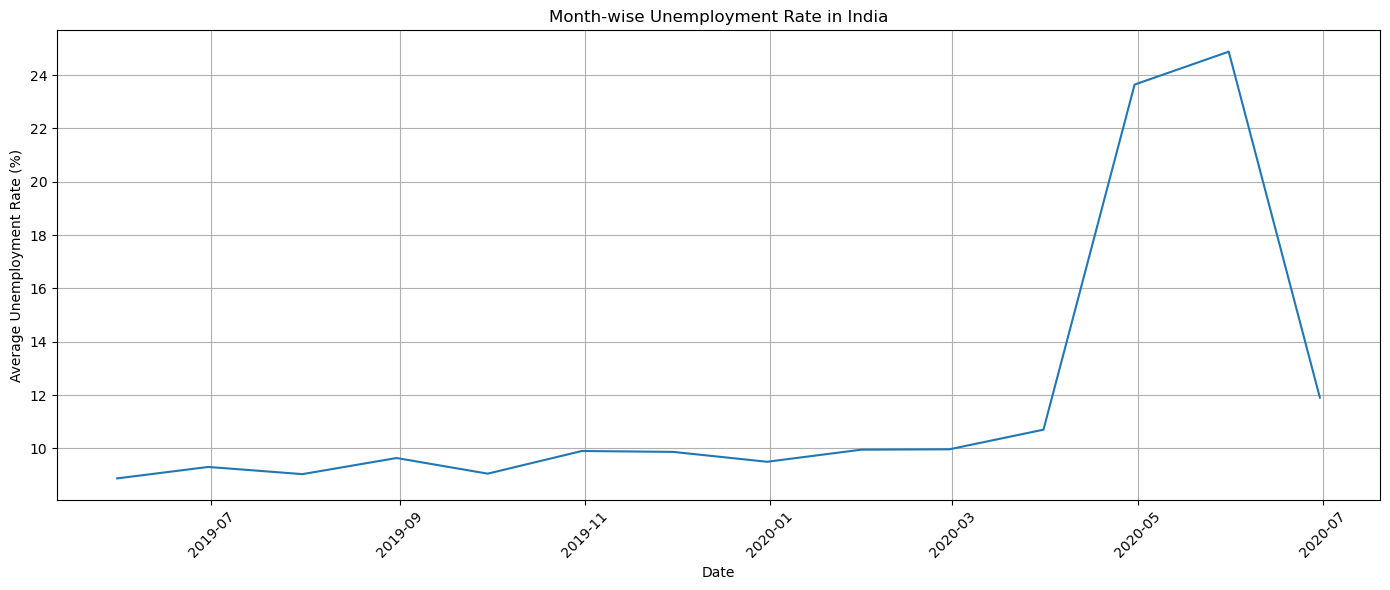

In [33]:
monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(14,6))

plt.plot(monthly_avg.index, monthly_avg.values)

plt.title('Month-wise Unemployment Rate in India')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

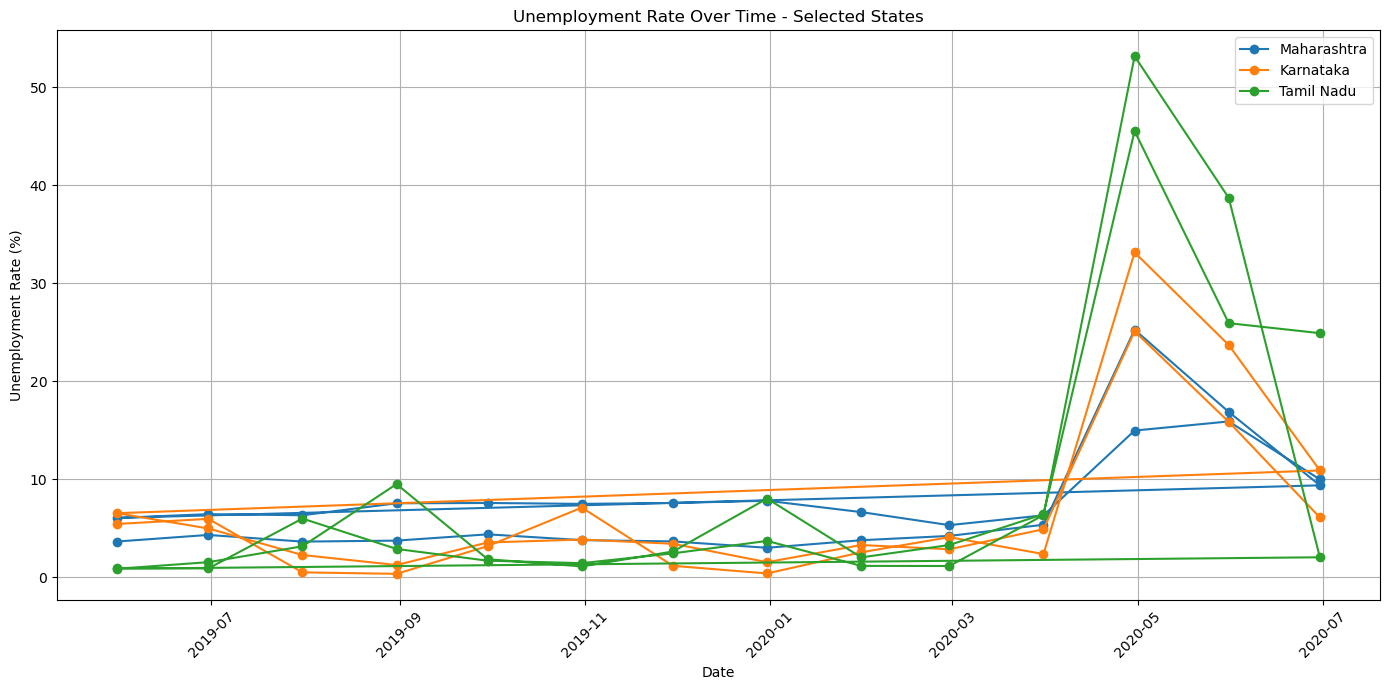

In [34]:
states = ['Maharashtra', 'Karnataka', 'Tamil Nadu']

plt.figure(figsize=(14,7))

for state in states:
    state_data = df[df['Region'] == state]
    plt.plot(
        state_data['Date'],
        state_data['Estimated Unemployment Rate (%)'],
        marker='o',
        label=state
    )

plt.title('Unemployment Rate Over Time - Selected States')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

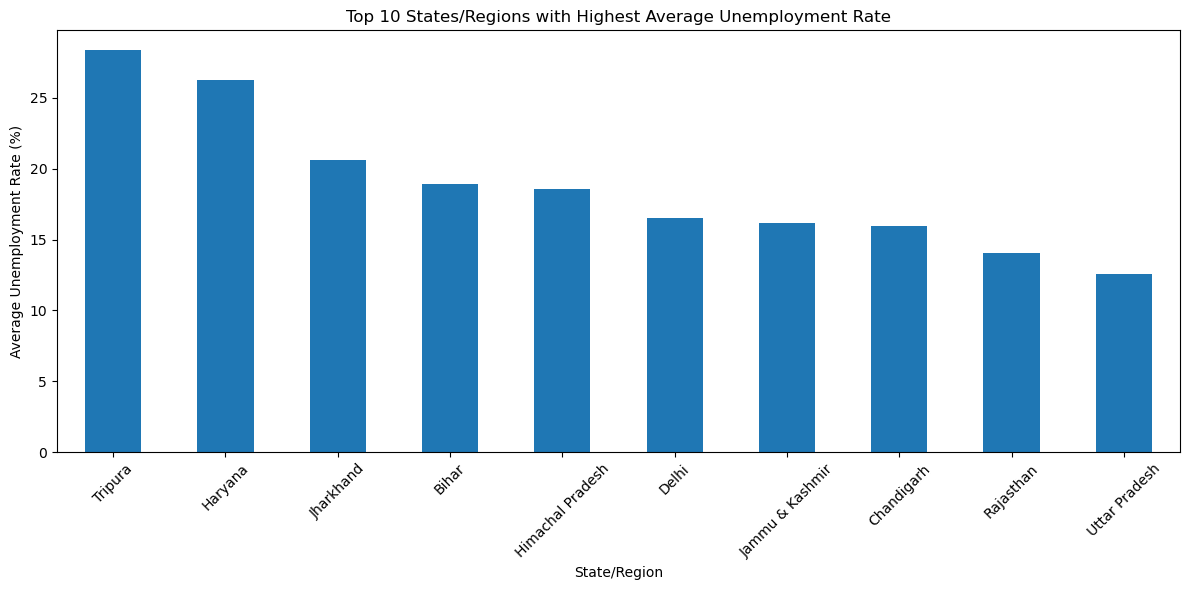

In [35]:
top10 = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top10.plot(kind='bar')

plt.title('Top 10 States/Regions with Highest Average Unemployment Rate')
plt.xlabel('State/Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

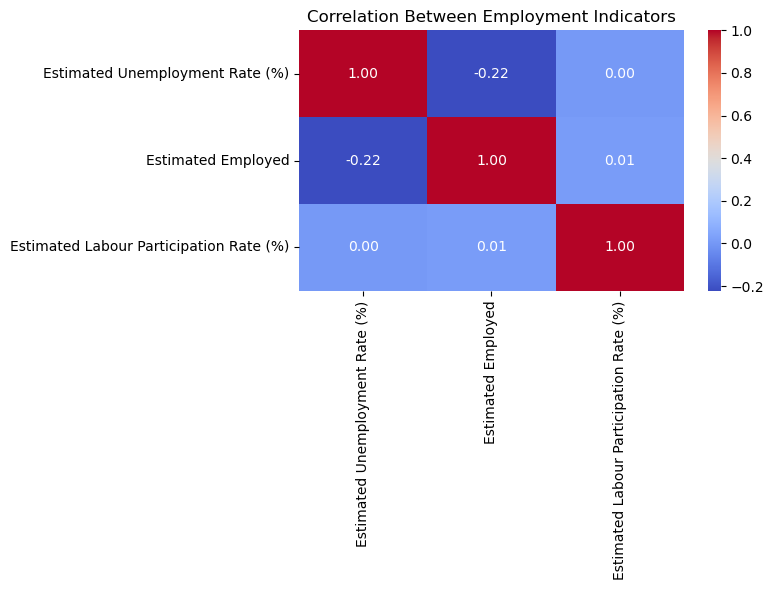

In [36]:
corr = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Between Employment Indicators')
plt.tight_layout()
plt.show()

In [37]:
pre_covid = df[df['Date'] < '2020-03-01']
post_covid = df[df['Date'] >= '2020-03-01']

pre_covid_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_covid_mean = post_covid['Estimated Unemployment Rate (%)'].mean()

print("Pre-COVID average unemployment rate:",
      round(pre_covid_mean, 2), "%")

print("Post-COVID average unemployment rate:",
      round(post_covid_mean, 2), "%")

Pre-COVID average unemployment rate: 9.51 %
Post-COVID average unemployment rate: 17.77 %


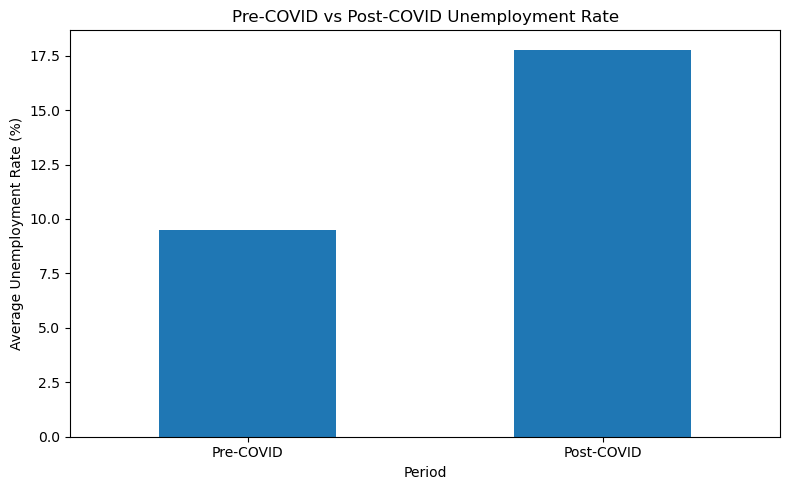

In [38]:
covid_comparison = pd.Series({
    'Pre-COVID': pre_covid_mean,
    'Post-COVID': post_covid_mean
})

plt.figure(figsize=(8,5))

covid_comparison.plot(kind='bar')

plt.title('Pre-COVID vs Post-COVID Unemployment Rate')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
percentage_change = (
    (post_covid_mean - pre_covid_mean)
    / pre_covid_mean
) * 100

print("Change in unemployment rate:",
      round(percentage_change, 2), "%")

Change in unemployment rate: 86.91 %


In [40]:
print("===== UNEMPLOYMENT ANALYSIS SUMMARY =====")
print("Average unemployment rate:", 
      round(df['Estimated Unemployment Rate (%)'].mean(), 2), "%")

print("Highest average unemployment region:",
      region_avg.index[0])

print("Highest average unemployment rate:",
      round(region_avg.iloc[0], 2), "%")

print("Pre-COVID average:",
      round(pre_covid_mean, 2), "%")

print("Post-COVID average:",
      round(post_covid_mean, 2), "%")

===== UNEMPLOYMENT ANALYSIS SUMMARY =====
Average unemployment rate: 11.79 %
Highest average unemployment region: Tripura
Highest average unemployment rate: 28.35 %
Pre-COVID average: 9.51 %
Post-COVID average: 17.77 %


# Conclusion

The analysis shows significant variation in unemployment across different regions and states of India. The unemployment rate changed considerably during the COVID-19 period. The comparison between pre-COVID and post-COVID data helps demonstrate the impact of the pandemic on employment conditions.

Overall, data analysis and visualization provide useful insights into unemployment trends and regional differences in India.